# Pipeline COCO — architecture finale

Système **100% non supervisé** d'apprentissage hiérarchique sur COCO Stuff :

1. **Modern Hopfield Network** : `z = softmax(β·Wx)` (remplace le WTA), surprise continue `S = ‖x - Wᵀz‖²`
2. **Neurogenèse libre** : croissance pilotée par la surprise, **sans plafond**
3. **Hiérarchie profonde** : couches créées par **convergence** (stabilité), tailles arbitraires
4. **Skip connections sans plafond** : inter-couches (C1→profond) + intra-couche
5. **Message passing** : consensus spatial + inhibition
6. **Condition de fin = ÉQUILIBRE** : la surprise converge → arrêt

L'entraînement se fait **classe par classe** (jamais tous les labels d'un coup).

## 0. Imports + chargement

In [1]:
# Pipeline COCO : Modern Hopfield + hiérarchie profonde + skip connections
import os, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Image as IImg, display
from recherche_agi import (HierarchicalCOCO, color_texture_features)


d = np.load('../data/coco_stuff/features_val.npz')
features = {int(k): v for k, v in d.items()}
d_in = next(iter(features.values())).shape[1]
print(f"Chargé : {len(features)} classes, dim {d_in}")

Chargé : 171 classes, dim 35


## 1. Entraînement par épochs (classe par classe) jusqu'à l'équilibre

In [2]:
model = HierarchicalCOCO(d_in=d_in, n_init=10, novelty_threshold=0.6, beta=5.0,
                         growth_scale=8.0, plateau_window=300)
classes = sorted(features.keys())[:30]
t0 = time.time()
epoch = 0
while True:
    epoch += 1
    for cls in classes:
        X = features[cls][:150]
        gw = int(np.ceil(np.sqrt(len(X)))); gh = int(np.ceil(len(X)/gw))
        model.step_image(X, np.full(len(X), cls), gh, gw)
    stop, reason = model.should_stop(equilibrium_window=500, equilibrium_tol=0.005)
    print(f"époch {epoch}: {model.summary()['layers']} couches, {sum(model.summary()['layer_sizes'])} neurones | équilibre={stop}")
    if stop or epoch >= 8:
        break
t = time.time() - t0

époch 1: 14 couches, 3314 neurones | équilibre=True


## 2. Tableau de performances

In [3]:
s = model.summary()
layers = model.layers + [model.layer]
sizes = [len(l.W) for l in layers]
sk = model.skips.summary()
print("=== TABLEAU DE PERFORMANCES ===")
print(f"Temps d'entraînement : {t:.1f}s ({t/60:.2f} min)")
print(f"Épochs exécutées     : {epoch}")
print(f"Neurones par couche  : {sizes}")
print(f"Nombre de couches    : {len(layers)}")
print(f"Total neurones       : {sum(sizes)}")
print(f"Skip connections     : total {sk['n_connections']} (inter {sk['inter_layer']}, intra {sk['intra_layer']})")
print(f"Condition de fin     : {reason}")

=== TABLEAU DE PERFORMANCES ===
Temps d'entraînement : 4.3s (0.07 min)
Épochs exécutées     : 1
Neurones par couche  : [286, 194, 437, 274, 276, 178, 325, 221, 138, 101, 231, 193, 329, 131]
Nombre de couches    : 14
Total neurones       : 3314
Skip connections     : total 5830 (inter 2971, intra 2859)
Condition de fin     : equilibre


## 3. Reconstruction sur TOUTES les couches

C:\Users\henry\Desktop\workspace\recherche-agi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the latest cached version of the module from C:\Users\henry\.cache\huggingface\modules\datasets_modules\datasets\shunk031--cocostuff\0cb0693fa398814099ab0697b71696861200330abf81ab0aff8993edd8964ba2 (last modified on Wed Aug 26 15:26:09 2026) since it couldn't be found locally at shunk031/cocostuff, or remotely on the Hugging Face Hub.


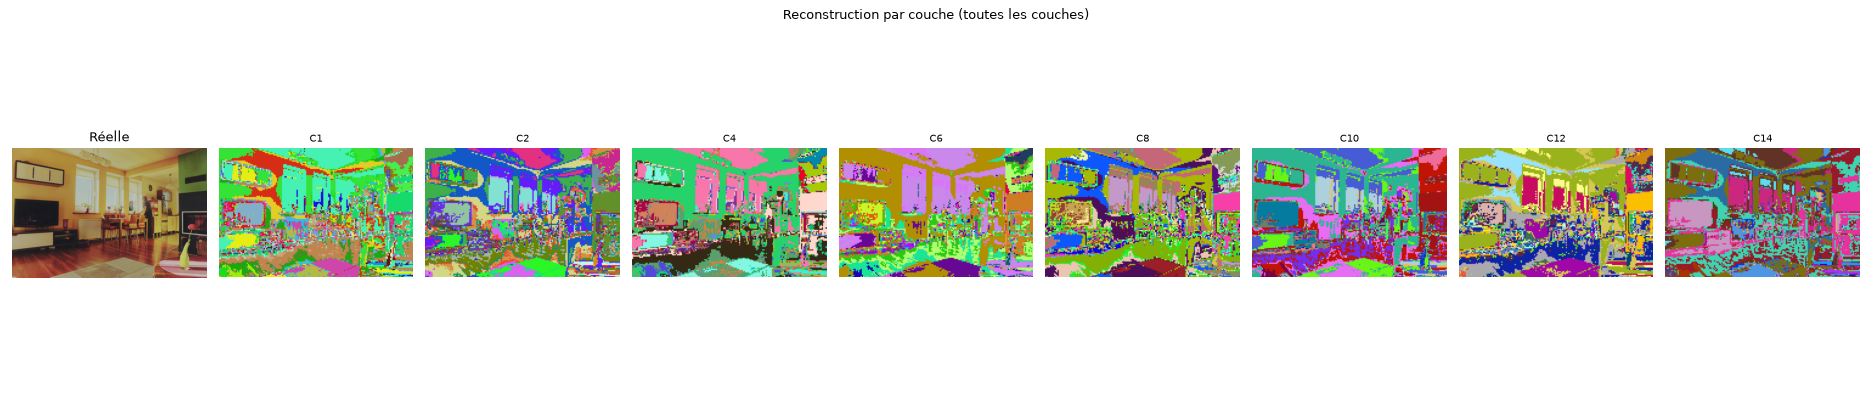

reconstruction sur toutes les couches générée


In [4]:
import os
os.makedirs("figs",exist_ok=True)
from datasets import load_dataset
ds = load_dataset('shunk031/cocostuff','stuff-thing',split='validation',streaming=True,trust_remote_code=True)
rng = np.random.default_rng(0)
PS = 4

def reconstruct_layer(zn, layer, gw, gh, PS):
    Wl = layer.W; winners = np.argmax(zn @ Wl.T, axis=1).reshape(gh, gw)
    pal = rng.integers(0, 255, (len(Wl), 3))
    lab = np.kron(winners, np.ones((PS, PS))).astype(int)
    ci = np.zeros((lab.shape[0], lab.shape[1], 3), dtype=np.uint8)
    for a in range(lab.shape[0]):
        for b in range(lab.shape[1]): ci[a,b] = pal[lab[a,b]]
    return ci

for n, x in enumerate(ds):
    if n >= 1: break
    img = np.array(x['image'])
    H, Wimg = img.shape[0]-img.shape[0]%PS, img.shape[1]-img.shape[1]%PS
    img_c = img[:H,:Wimg]; gh, gw = H//PS, Wimg//PS
    feats = np.zeros((gh*gw, d_in))
    for i in range(0, H, PS):
        for j in range(0, Wimg, PS):
            feats[(i//PS)*gw+(j//PS)] = color_texture_features(img_c[i:i+PS, j:j+PS])
    zn = feats/(np.linalg.norm(feats,axis=1,keepdims=True)+1e-8)
    n_show = min(8, len(layers))
    idxs = np.linspace(0, len(layers)-1, n_show).astype(int)
    fig, axes = plt.subplots(1, n_show+1, figsize=((n_show+1)*2.6, 5))
    axes[0].imshow(img); axes[0].set_title("Réelle"); axes[0].axis('off')
    for kk, li in enumerate(idxs):
        ci = reconstruct_layer(zn, layers[li], gw, gh, PS)
        axes[kk+1].imshow(ci); axes[kk+1].set_title(f"C{li+1}", fontsize=9); axes[kk+1].axis('off')
    plt.suptitle("Reconstruction par couche (toutes les couches)")
    plt.tight_layout()
    plt.savefig('figs/coco_pipeline_recon.png', dpi=80); plt.close()
    display(IImg('figs/coco_pipeline_recon.png'))
    print("reconstruction sur toutes les couches générée")

## 4. Analyse

In [5]:
print("=== ANALYSE FINALE ===")
print(f"1. Modern Hopfield : z = softmax(βWx), surprise continue")
print(f"2. Neurogenèse libre sans plafond : {sum(sizes)} neurones")
print(f"3. Hiérarchie : {len(layers)} couches, tailles {sizes}")
print(f"4. Skip connections : {sk['n_connections']} (inter {sk['inter_layer']}, intra {sk['intra_layer']})")
print(f"5. Fin par équilibre : {reason} après {epoch} époch(s), {t:.1f}s")

=== ANALYSE FINALE ===
1. Modern Hopfield : z = softmax(βWx), surprise continue
2. Neurogenèse libre sans plafond : 3314 neurones
3. Hiérarchie : 14 couches, tailles [286, 194, 437, 274, 276, 178, 325, 221, 138, 101, 231, 193, 329, 131]
4. Skip connections : 5830 (inter 2971, intra 2859)
5. Fin par équilibre : equilibre après 1 époch(s), 4.3s
